<a href="https://colab.research.google.com/github/vikrantyadav11234/ML_Practice/blob/main/Model_building_Homestays_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_log_error



In [ ]:
df= pd.read_csv('/content/df_encoded.csv')
df.head()

,Unnamed: 0.1,Unnamed: 0,log_price,accommodates,bathrooms,cancellation_policy,cleaning_fee,host_response_rate,instant_bookable,number_of_reviews,...,property_type_Train,property_type_Treehouse,property_type_Vacation home,property_type_Villa,property_type_Yurt,bed_type_Airbed,bed_type_Couch,bed_type_Futon,bed_type_Pull-out Sofa,bed_type_Real Bed
0,0,0,5.010635,3,1.0,3,1,1.0,0,2,...,0,0,0,0,0,0,0,0,0,1
1,1,1,5.129899,7,1.0,3,1,1.0,1,6,...,0,0,0,0,0,0,0,0,0,1
2,2,2,4.976734,5,1.0,2,1,1.0,1,10,...,0,0,0,0,0,0,0,0,0,1
3,3,3,6.620073,4,1.0,1,1,1.0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,4,4,4.744932,2,1.0,2,1,1.0,1,4,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
df.drop(columns=['Unnamed: 0.1','Unnamed: 0'], inplace= True)

In [ ]:
df.head()

,log_price,accommodates,bathrooms,cancellation_policy,cleaning_fee,host_response_rate,instant_bookable,number_of_reviews,review_scores_rating,zipcode,...,property_type_Train,property_type_Treehouse,property_type_Vacation home,property_type_Villa,property_type_Yurt,bed_type_Airbed,bed_type_Couch,bed_type_Futon,bed_type_Pull-out Sofa,bed_type_Real Bed
0,5.010635,3,1.0,3,1,1.0,0,2,100.0,106,...,0,0,0,0,0,0,0,0,0,1
1,5.129899,7,1.0,3,1,1.0,1,6,93.0,20,...,0,0,0,0,0,0,0,0,0,1
2,4.976734,5,1.0,2,1,1.0,1,10,92.0,27,...,0,0,0,0,0,0,0,0,0,1
3,6.620073,4,1.0,1,1,1.0,0,0,96.0,651,...,0,0,0,0,0,0,0,0,0,1
4,4.744932,2,1.0,2,1,1.0,1,4,40.0,211,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
X= df.drop(columns=['log_price'], axis=1)
Y= df['log_price']

In [ ]:
# split the data
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.metrics import mean_squared_error

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=101)

### first we compare all three regression model in early stage

In [ ]:
models= {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(),
    'Gradient Boosting': GradientBoostingRegressor()
}

In [ ]:
for name, model in models.items():
  model.fit(x_train, y_train)
  y_pred= model.predict(x_test)
  mse= mean_squared_error(y_test, y_pred)
  print(f'{name} MSE:',mse)


Linear Regression MSE: 0.1889488480811355
Random Forest MSE: 0.1687766422098558
Gradient Boosting MSE: 0.16788776559129823


# After sampling linear regression model

In [ ]:
# sampling
sc= StandardScaler()
x_train_sc= sc.fit_transform(x_train)
x_test_sc= sc.transform(x_test)

In [ ]:
# Now apply linear regression again
le_model_1= LinearRegression()

In [ ]:
le_model_1.fit(x_train_sc, y_train)
y_pred_lr_model_1= le_model_1.predict(x_test_sc)
mse= mean_squared_error(y_test, y_pred_lr_model_1)
print(f'Linear Regression with sampling MSE:', mse)

Linear Regression with sampling MSE: 0.1890008825370061


In [ ]:
# Define the parameter grid for Linear Regression hyperparameter tuning
param_grid_lr = {
    'fit_intercept': [True, False],   # Whether to calculate the intercept for this model

    'copy_X': [True, False]            # Whether to copy the input data before fitting the model
}

In [ ]:
from sklearn.model_selection import GridSearchCV
# Initialize the Linear Regression model
lr_model = LinearRegression()

# Perform grid search with cross-validation for Linear Regression
grid_search_lr = GridSearchCV(lr_model, param_grid_lr, cv=5, scoring='neg_mean_squared_error')

# Fit the grid search model to the data
grid_search_lr.fit(x_train, y_train)

# Get the best hyperparameters and the corresponding mean cross-validated score
best_params_lr = grid_search_lr.best_params_
best_score_lr = grid_search_lr.best_score_

print("Best Hyperparameters for Linear Regression:", best_params_lr)
print("Best Mean Cross-Validated Score for Linear Regression:", -best_score_lr)

Best Hyperparameters for Linear Regression: {'copy_X': True, 'fit_intercept': True}
Best Mean Cross-Validated Score for Linear Regression: 0.18877197547066732


In [ ]:
# Initialize Linear Regression model with best hyperparameters
best_lr_model = LinearRegression(**best_params_lr)

# Fit the model to the training data
best_lr_model.fit(x_train, y_train)

# Predict the target variable on the test set
y_pred_best_lr = best_lr_model.predict(x_test)

# Calculate mean squared error (MSE) on the test set
mse_lr = mean_squared_error(y_test, y_pred_best_lr)

print("Mean Squared Error (MSE) on Test Set for Linear Regression:", mse_lr)

Mean Squared Error (MSE) on Test Set for Linear Regression: 0.1889488480811355


In [ ]:
# Get the coefficients of the Linear Regression model
coefficients_lr = best_lr_model.coef_

# Create a DataFrame to display feature importance (coefficients)
feature_importance_lr = pd.DataFrame({'Feature': X.columns, 'Importance': coefficients_lr})
feature_importance_lr = feature_importance_lr.sort_values(by='Importance', ascending=False)
print(feature_importance_lr)

                          Feature  Importance
49    property_type_Parking Space    0.854631
24                        city_SF    0.523150
16      room_type_Entire home/apt    0.479220
32  property_type_Casa particular    0.430342
46       property_type_Lighthouse    0.428522
..                            ...         ...
51             property_type_Tent   -0.422492
18          room_type_Shared room   -0.431252
43              property_type_Hut   -0.517204
37             property_type_Dorm   -0.566078
41           property_type_Hostel   -0.749476

[65 rows x 2 columns]


In [ ]:
pip install shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.5/540.5 kB 8.8 MB/s eta 0:00:00


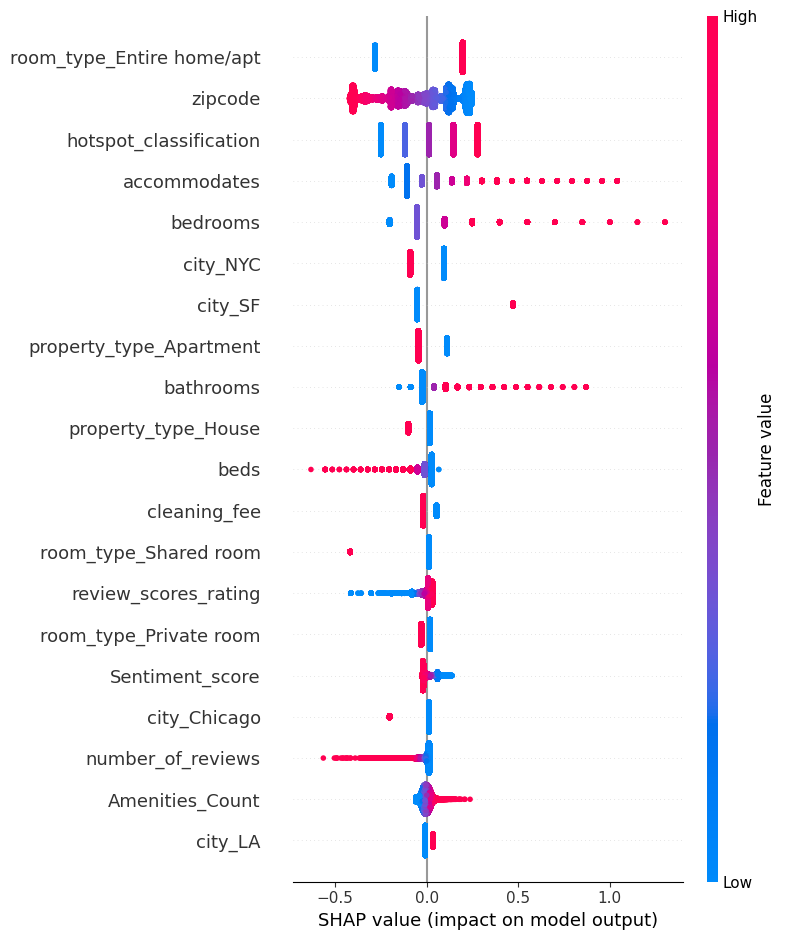

In [ ]:
import shap

# Initialize the explainer with the trained Random Forest model and the training data
explainer = shap.Explainer(best_lr_model, x_train)

# Compute SHAP values for the entire training set
shap_values = explainer.shap_values(x_train)

# Visualize SHAP summary plot
shap.summary_plot(shap_values, x_train)

In [ ]:


# Calculate Root Mean Squared Error (RMSE) and R-squared for evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred_best_lr))
r2 = r2_score(y_test, y_pred_best_lr)

print("Root Mean Squared Error (RMSE) on Test Set:", rmse)
print("R-squared on Test Set:", r2)

Root Mean Squared Error (RMSE) on Test Set: 0.4346824681087742
R-squared on Test Set: 0.6309415232419788


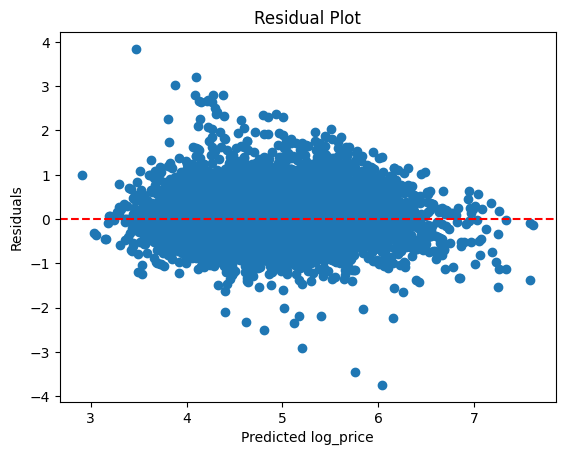

In [ ]:
# Analyze residuals
residuals = y_test - y_pred_best_lr

# Plot residuals against predicted values
plt.scatter(y_pred_best_lr, residuals)
plt.xlabel("Predicted log_price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

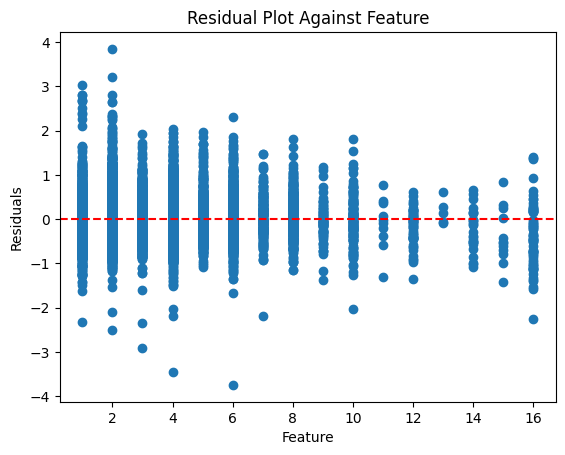

In [ ]:
# Alternatively, you can plot residuals against specific features to check for patterns
# For example:
plt.scatter(x_test['accommodates'], residuals)
plt.xlabel("Feature")
plt.ylabel("Residuals")
plt.title("Residual Plot Against Feature")
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

# With Random Forest Model

In [ ]:
# Define the parameter grid for Random Forest hyperparameter tuning
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 0.5]
}

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Initialize Random Forest model
rf_model = RandomForestRegressor(random_state=101)

# Perform grid search with cross-validation
grid_search_rf = GridSearchCV(rf_model, param_grid_rf, cv=5, scoring='neg_mean_squared_error')
grid_search_rf.fit(x_train, y_train)

# Get the best Random Forest model
best_rf_model = grid_search_rf.best_estimator_

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:413: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0` or remove this parameter as it is also the default value for RandomForestRegressors and ExtraTreesRegressors.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:413: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0` or remove this parameter as it is also the default value for RandomForestRegressors and ExtraTreesRegressors.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:413: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0` or remove this parameter as it is also the default value for RandomForestRegressors

KeyboardInterrupt: 

In [ ]:
# Print the best hyperparameters and corresponding mean cross-validated score
print("Best Hyperparameters for Random Forest:", grid_search_rf.best_params_)
print("Best Mean Cross-Validated Score for Random Forest:", -grid_search_rf.best_score_)